In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv(r'C:\Users\saman\OneDrive\Desktop\Engineering Workbench\data\yacht_hydrodynamics.csv')
df.head()

,LCB,Prismatic_Coefficient,Length_Displacement_Ratio,Beam_Draught_Ratio,Length_Beam_Ratio,Froude_Number,Residuary_Resistance_per_Unit_Weight_Displacement
0,-2.3,0.568,4.78,3.99,3.17,0.125,0.11
1,-2.3,0.568,4.78,3.99,3.17,0.150,0.27
2,-2.3,0.568,4.78,3.99,3.17,0.175,0.47
3,-2.3,0.568,4.78,3.99,3.17,0.200,0.78
4,-2.3,0.568,4.78,3.99,3.17,0.225,1.18


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 7 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   LCB                                                308 non-null    float64
 1   Prismatic_Coefficient                              308 non-null    float64
 2   Length_Displacement_Ratio                          308 non-null    float64
 3   Beam_Draught_Ratio                                 308 non-null    float64
 4   Length_Beam_Ratio                                  308 non-null    float64
 5   Froude_Number                                      308 non-null    float64
 6   Residuary_Resistance_per_Unit_Weight_Displacement  308 non-null    float64
dtypes: float64(7)
memory usage: 17.0 KB


In [48]:
df.describe()

,LCB,Prismatic_Coefficient,Length_Displacement_Ratio,Beam_Draught_Ratio,Length_Beam_Ratio,Froude_Number,Residuary_Resistance_per_Unit_Weight_Displacement
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,-2.381818,0.564136,4.788636,3.936818,3.206818,0.287500,10.495357
std,1.513219,0.023290,0.253057,0.548193,0.247998,0.100942,15.160490
min,-5.000000,0.530000,4.340000,2.810000,2.730000,0.125000,0.010000
25%,-2.400000,0.546000,4.770000,3.750000,3.150000,0.200000,0.777500
50%,-2.300000,0.565000,4.780000,3.955000,3.150000,0.287500,3.065000
75%,-2.300000,0.574000,5.100000,4.170000,3.510000,0.375000,12.815000
max,0.000000,0.600000,5.140000,5.350000,3.640000,0.450000,62.420000


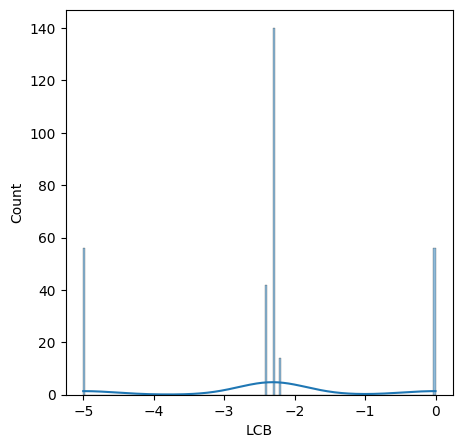

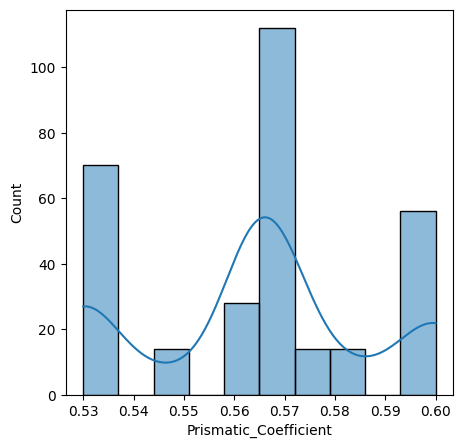

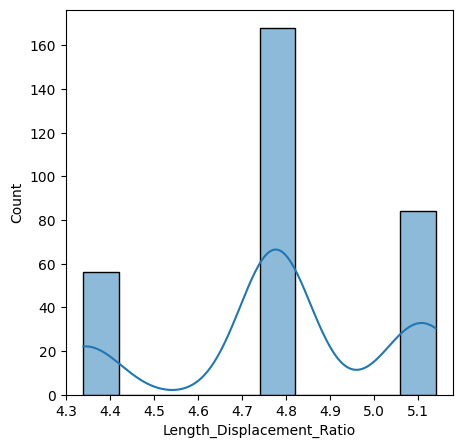

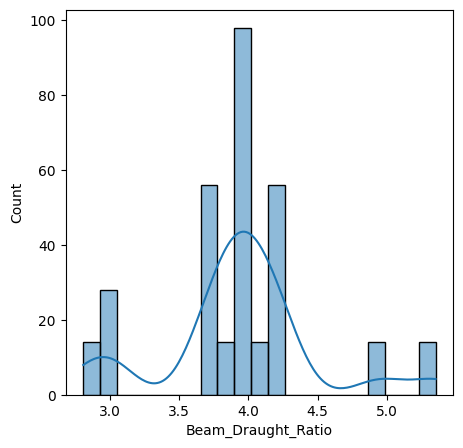

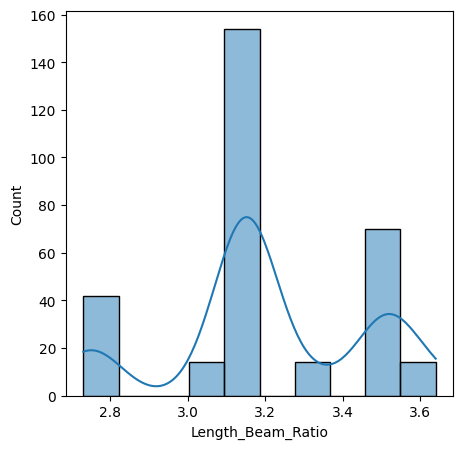

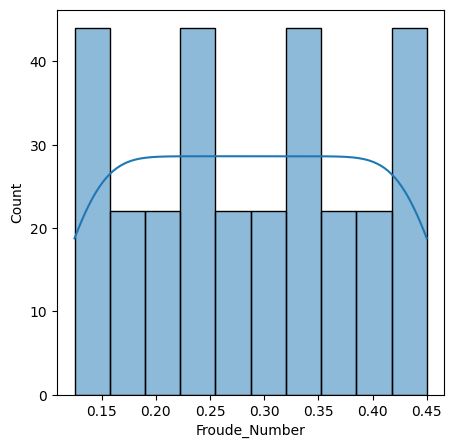

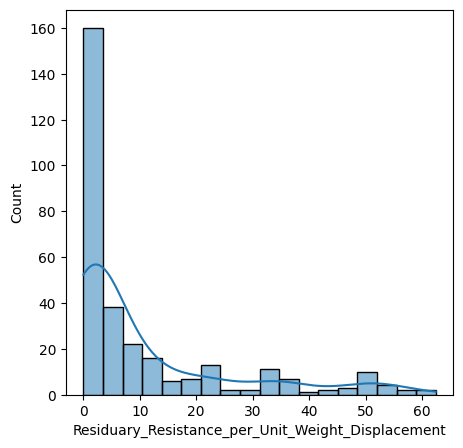

In [49]:
for col in df.columns:
    fig, ax = plt.subplots(figsize=(5, 5))
    sns.histplot(df, x=col, kde=True, ax=ax)
    plt.show()

<Axes: >

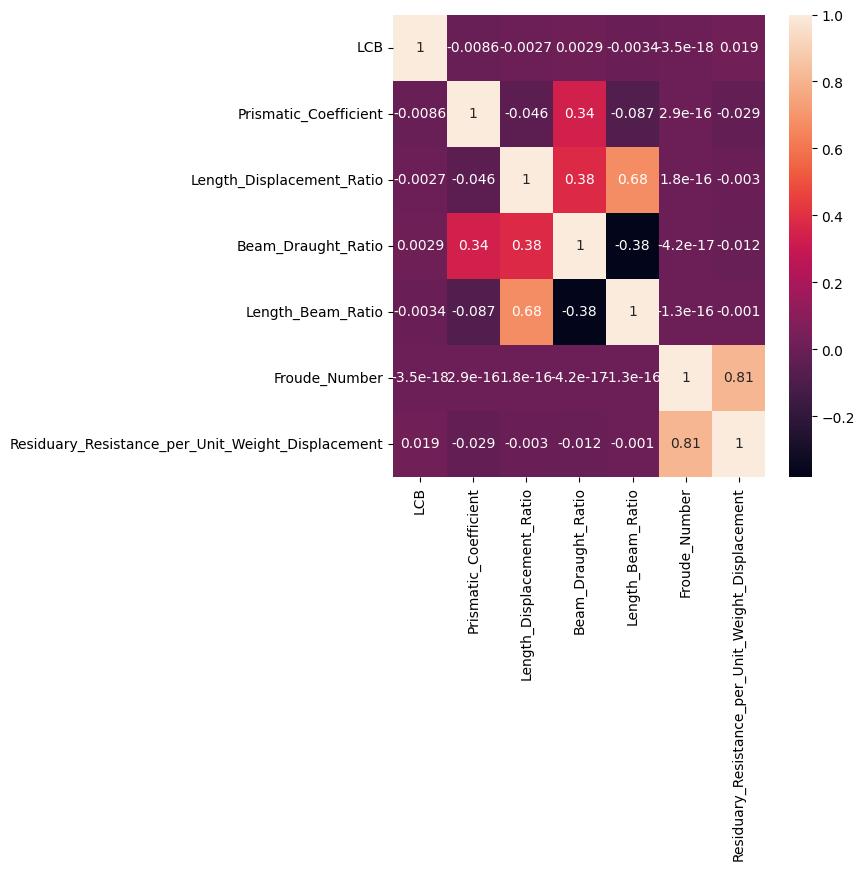

In [50]:
corr = df.corr()
figsize = plt.subplots(figsize=(6,6))
sns.heatmap(corr, annot=True)

In [51]:
df.columns

Index(['LCB', 'Prismatic_Coefficient', 'Length_Displacement_Ratio',
       'Beam_Draught_Ratio', 'Length_Beam_Ratio', 'Froude_Number',
       'Residuary_Resistance_per_Unit_Weight_Displacement'],
      dtype='object')

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

numeric_pipeline=Pipeline([
    ('scaler', StandardScaler())
])

log_transform = PowerTransformer(method='yeo-johnson')

preprocessor = ColumnTransformer(transformers=[
    ('numerical', numeric_pipeline, df.columns[:-1]),
])

X, y = df.drop(labels=['Residuary_Resistance_per_Unit_Weight_Displacement'], axis=1), df['Residuary_Resistance_per_Unit_Weight_Displacement']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = log_transform.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_test = log_transform.transform(y_test.to_numpy().reshape(-1, 1))

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

model_pipeline = Pipeline([
    ('preprocesser', preprocessor),
    ('model', LinearRegression())
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

y_pred = log_transform.inverse_transform(y_pred)
y_test_original = log_transform.inverse_transform(y_test)

r2 = r2_score(y_test_original, y_pred)

r2

0.9750771127589422

In [54]:
#tests prediction

new_ship = pd.DataFrame(
    [[-2.3, 0.568, 4.78, 3.99, 3.17, 0.25]],
    columns=X.columns
)

pred = model_pipeline.predict(new_ship)
pred = log_transform.inverse_transform(pred.reshape(-1, 1)).ravel()

pred

array([2.06336627])

In [55]:
import joblib

joblib.dump(
    model_pipeline,
    r"C:\Users\saman\OneDrive\Desktop\Engineering Workbench\joblib objects\model.pkl"
)

joblib.dump(
    log_transform,
    r"C:\Users\saman\OneDrive\Desktop\Engineering Workbench\joblib objects\transformer.pkl"
)

joblib.dump(
    X.columns,
    r"C:\Users\saman\OneDrive\Desktop\Engineering Workbench\joblib objects\cols.pkl"
)

['C:\\Users\\saman\\OneDrive\\Desktop\\Engineering Workbench\\joblib objects\\cols.pkl']